# Output Classifier — Domain-Constrained Chatbot Guardrails (S1)

Binary classifier on the **LLM response** to detect whether Llama complied with a query (label=1) or refused it (label=0).
Together with the input classifier, this gives a two-stage filter for the S1 strategy.

**Setup**
- Model: `roberta-base` (~125M params)
- Hardware: Google Colab Pro, H100
- Train: 5k responses on training queries (`responses_labeled_5k.csv`)
- Test: 500 responses on eval queries (`responses_labeled_eval.csv`)
- Label: `predicted_compliance` (GPT-4o-mini judge, ~90% agreement with manual review per the README)

**Positive class = COMPLIED.** That's the guardrail failure mode we want to detect.

**Metrics & graphs**
- Confusion matrix per epoch (validation)
- Confusion matrix on test + classification report
- ROC curve + AUC
- Precision-Recall curve + average precision (better for imbalanced data)
- Confidence histogram by class
- Per-epoch metrics table


In [23]:
!pip install -q -U transformers datasets accelerate scikit-learn seaborn matplotlib

In [24]:
import os, random, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

SEED = 42
set_seed(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA H100 80GB HBM3
Memory: 85.0 GB


In [25]:
# ---- Hyperparameters ----
CONFIG = {
    "model_name": "roberta-base",
    "max_length": 512,
    "batch_size": 32,
    "eval_batch_size": 64,
    "num_epochs": 3,           # output classifier converges quickly; 3 is enough
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "val_split": 0.1,          # 10% of training -> validation
    "output_dir": "./output_classifier_output",
    # Train on the 5k file, test on the 500-row eval file.
    # If you want the reverse, swap these two paths.
    "train_csv_path": "/content/responses_labeled_5k.csv",
    "test_csv_path":  "/content/responses_labeled_eval.csv",
    "label_col": "predicted_compliance",  # 1 = COMPLIED, 0 = REFUSED
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
LABELS = ("REFUSED", "COMPLIED")  # 0, 1


## 1. Load data + quick EDA

In [26]:
train_df = pd.read_csv(CONFIG["train_csv_path"])
test_df  = pd.read_csv(CONFIG["test_csv_path"])

# Drop columns we don't need for modeling
for df in (train_df, test_df):
    for col in ("__index_level_0__", "prompt_word_count", "nli_confidence"):
        if col in df.columns:
            df.drop(columns=col, inplace=True)
    # Drop any rows where the label or response is null
    df.dropna(subset=[CONFIG["label_col"], "llama_response"], inplace=True)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print(f"Columns: {train_df.columns.tolist()}\n")

print(f"Train class balance ({CONFIG['label_col']}):")
print(f"  {train_df[CONFIG['label_col']].value_counts().to_dict()}")
print(f"  COMPLIED rate: {train_df[CONFIG['label_col']].mean():.3f}")
print(f"\nTest class balance:")
print(f"  {test_df[CONFIG['label_col']].value_counts().to_dict()}")
print(f"  COMPLIED rate: {test_df[CONFIG['label_col']].mean():.3f}")

# If off_topic is present, also break down by topic
if "off_topic" in train_df.columns:
    print(f"\nTrain compliance breakdown:")
    breakdown = train_df.groupby("off_topic")[CONFIG["label_col"]].agg(["count", "mean"])
    breakdown.columns = ["n", "comply_rate"]
    print(breakdown)


Train rows: 5000 | Test rows: 500
Columns: ['system_prompt', 'prompt', 'off_topic', 'llama_response', 'predicted_compliance']

Train class balance (predicted_compliance):
  {1: 4043, 0: 957}
  COMPLIED rate: 0.809

Test class balance:
  {1: 420, 0: 80}
  COMPLIED rate: 0.840

Train compliance breakdown:
              n  comply_rate
off_topic                   
0          2500       0.9228
1          2500       0.6944


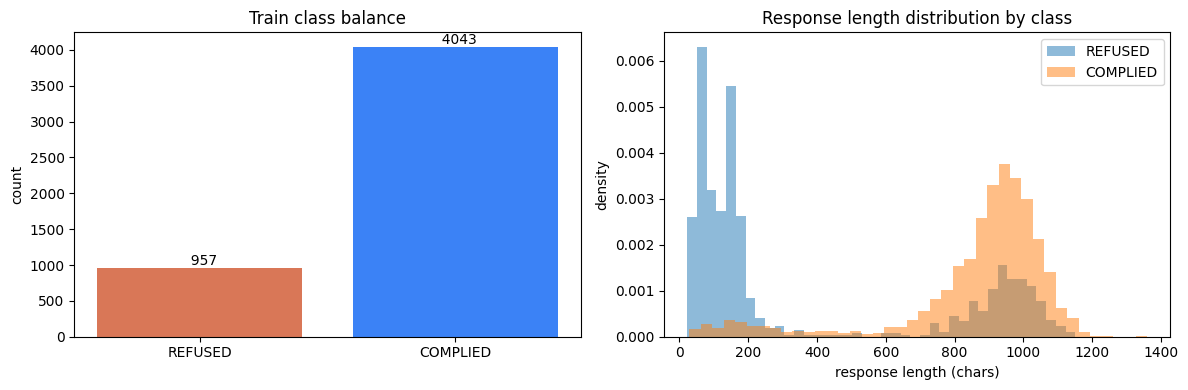

Mean response length — REFUSED: 363 chars
Mean response length — COMPLIED: 863 chars
(Refusals are typically much shorter — a sanity check that the dataset has clear signal.)


In [27]:
# Visualize class balance + response length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = train_df[CONFIG["label_col"]].value_counts().sort_index()
axes[0].bar([LABELS[i] for i in counts.index], counts.values, color=["#d97757", "#3b82f6"])
axes[0].set_title("Train class balance")
axes[0].set_ylabel("count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"  {v}", ha="center", va="bottom")

# Response length by class
train_df["resp_len_chars"] = train_df["llama_response"].str.len()
for lab in (0, 1):
    sub = train_df[train_df[CONFIG["label_col"]] == lab]["resp_len_chars"]
    axes[1].hist(sub, bins=40, alpha=0.5, label=LABELS[lab], density=True)
axes[1].set_xlabel("response length (chars)")
axes[1].set_ylabel("density")
axes[1].set_title("Response length distribution by class")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Mean response length — REFUSED: {train_df[train_df[CONFIG['label_col']]==0]['resp_len_chars'].mean():.0f} chars")
print(f"Mean response length — COMPLIED: {train_df[train_df[CONFIG['label_col']]==1]['resp_len_chars'].mean():.0f} chars")
print("(Refusals are typically much shorter — a sanity check that the dataset has clear signal.)")


In [28]:
# Stratified split inside the training set
train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=CONFIG["val_split"],
    stratify=train_df[CONFIG["label_col"]],
    random_state=SEED,
)
print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)} | Test: {len(test_df)}")
print(f"Train balance: {train_split_df[CONFIG['label_col']].value_counts().to_dict()}")
print(f"Val   balance: {val_split_df[CONFIG['label_col']].value_counts().to_dict()}")
print(f"Test  balance: {test_df[CONFIG['label_col']].value_counts().to_dict()}")


Train: 4500 | Val: 500 | Test: 500
Train balance: {1: 3639, 0: 861}
Val   balance: {1: 404, 0: 96}
Test  balance: {1: 420, 0: 80}


## 2. Tokenize

Three text fields, one 512-token budget. We pack `system_prompt + prompt` into segment A (the "context") and `llama_response` into segment B (the "thing being classified"). `longest_first` truncation so if anything has to be cut, it cuts from whichever side is bigger — usually the system_prompt.


In [29]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def build_context(system_prompt: str, prompt: str) -> str:
    """Combine system prompt and user query into a single context string."""
    return f"{system_prompt.strip()}\n\nUser query: {prompt.strip()}"

# Token length sanity check on a sample
sample = train_split_df.sample(min(500, len(train_split_df)), random_state=SEED)
def _len(row):
    ctx = build_context(row["system_prompt"], row["prompt"])
    return len(tokenizer(ctx, row["llama_response"])["input_ids"])
sample_lens = sample.apply(_len, axis=1)
print(f"Triple token length — mean: {sample_lens.mean():.0f}, p50: {sample_lens.median():.0f}, "
      f"p95: {sample_lens.quantile(0.95):.0f}, max: {sample_lens.max()}")
print(f"% over max_length ({CONFIG['max_length']}): {(sample_lens > CONFIG['max_length']).mean()*100:.1f}%")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (594 > 512). Running this sequence through the model will result in indexing errors


Triple token length — mean: 322, p50: 342, p95: 439, max: 619
% over max_length (512): 0.4%


In [30]:
def tokenize_triple(batch):
    contexts = [
        build_context(sp, p) for sp, p in zip(batch["system_prompt"], batch["prompt"])
    ]
    return tokenizer(
        contexts,
        batch["llama_response"],
        truncation="longest_first",
        max_length=CONFIG["max_length"],
        padding=False,
    )

def df_to_tokenized(df):
    keep = ["system_prompt", "prompt", "llama_response", CONFIG["label_col"]]
    ds = Dataset.from_pandas(
        df[keep].rename(columns={CONFIG["label_col"]: "labels"}),
        preserve_index=False,
    )
    return ds.map(
        tokenize_triple, batched=True,
        remove_columns=["system_prompt", "prompt", "llama_response"],
    )

train_ds = df_to_tokenized(train_split_df)
val_ds   = df_to_tokenized(val_split_df)
test_ds  = df_to_tokenized(test_df)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Sample tokenized keys: {list(train_ds[0].keys())}")
print(f"Input length of first example: {len(train_ds[0]['input_ids'])}")


Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train: 4500 | Val: 500 | Test: 500
Sample tokenized keys: ['labels', 'input_ids', 'attention_mask']
Input length of first example: 136


## 3. Model

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=2,
    id2label={0: "REFUSED", 1: "COMPLIED"},
    label2id={"REFUSED": 0, "COMPLIED": 1},
)
print(f"Model: {CONFIG['model_name']}  |  {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base  |  124.6M params


## 4. Metrics, confusion matrix, callback

In [32]:
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS,
        cbar=False, ax=ax,
    )
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()

    tn, fp, fn, tp = cm.ravel()
    recall_complied = tp / (tp + fn) if (tp + fn) else 0.0       # how many actual COMPLIED we caught
    precision_complied = tp / (tp + fp) if (tp + fp) else 0.0    # of predicted COMPLIED, how many right
    recall_refused = tn / (tn + fp) if (tn + fp) else 0.0        # how many actual REFUSED we caught
    acc = (tp + tn) / cm.sum()
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  accuracy                    = {acc:.4f}")
    print(f"  recall  (COMPLIED detected) = {recall_complied:.4f}")
    print(f"  precision (COMPLIED)        = {precision_complied:.4f}")
    print(f"  recall  (REFUSED detected)  = {recall_refused:.4f}")
    return cm


In [33]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", pos_label=1, zero_division=0)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": acc,
        "precision_complied": p,
        "recall_complied": r,
        "f1_complied": f1,
        "f1_macro": f1_macro,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


class EpochCMCallback(TrainerCallback):
    def __init__(self):
        self.history = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        epoch = state.epoch if state.epoch is not None else 0
        tn = metrics.get("eval_tn"); fp = metrics.get("eval_fp")
        fn = metrics.get("eval_fn"); tp = metrics.get("eval_tp")
        if None in (tn, fp, fn, tp):
            return
        cm = np.array([[tn, fp], [fn, tp]])
        self.history.append({"epoch": epoch, "cm": cm.tolist(), "metrics": dict(metrics)})

        fig, ax = plt.subplots(figsize=(5.0, 4.0))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"Validation CM — epoch {epoch:.0f}")
        plt.tight_layout(); plt.show()
        print(f"  epoch {epoch:.0f}  |  acc={metrics.get('eval_accuracy', 0):.4f}  "
              f"f1_macro={metrics.get('eval_f1_macro', 0):.4f}  "
              f"f1_complied={metrics.get('eval_f1_complied', 0):.4f}  "
              f"recall_complied={metrics.get('eval_recall_complied', 0):.4f}")


## 5. Train

In [34]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch_size"],
    learning_rate=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    warmup_ratio=CONFIG["warmup_ratio"],
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",   # macro F1 since class imbalance
    greater_is_better=True,
    save_total_limit=2,
    bf16=use_bf16,                      # RoBERTa is stable in bf16
    fp16=False,
    report_to="none",
    seed=SEED,
    dataloader_pin_memory=True,
    remove_unused_columns=True,
)

cm_cb = EpochCMCallback()

import torch.nn.functional as F
from torch import nn

# Compute balanced class weights from training distribution
n_total = len(train_split_df)
n_ref = (train_split_df[CONFIG["label_col"]] == 0).sum()
n_com = (train_split_df[CONFIG["label_col"]] == 1).sum()
class_weights = torch.tensor([
    n_total / (2 * n_ref),     # weight for REFUSED
    n_total / (2 * n_com),     # weight for COMPLIED
], dtype=torch.float)
print(f"Class weights — REFUSED: {class_weights[0]:.3f}, COMPLIED: {class_weights[1]:.3f}")

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = F.cross_entropy(
            outputs.logits, labels,
            weight=self.class_weights.to(outputs.logits.device),
        )
        return (loss, outputs) if return_outputs else loss


trainer = WeightedTrainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics, callbacks=[cm_cb],
    class_weights=class_weights,
)

print(f"BF16: {use_bf16}")
print(f"Total training steps: {len(train_ds) // CONFIG['batch_size'] * CONFIG['num_epochs']}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Class weights — REFUSED: 2.613, COMPLIED: 0.618
BF16: True
Total training steps: 420


Epoch,Training Loss,Validation Loss,Accuracy,Precision Complied,Recall Complied,F1 Complied,F1 Macro,Tn,Fp,Fn,Tp
1,0.359858,0.268784,0.894000,0.958225,0.908416,0.932656,0.841915,80,16,37,367
2,0.260268,0.290442,0.898000,0.949109,0.923267,0.936010,0.842389,76,20,31,373
3,0.227203,0.274693,0.916000,0.952500,0.943069,0.947761,0.866738,77,19,23,381


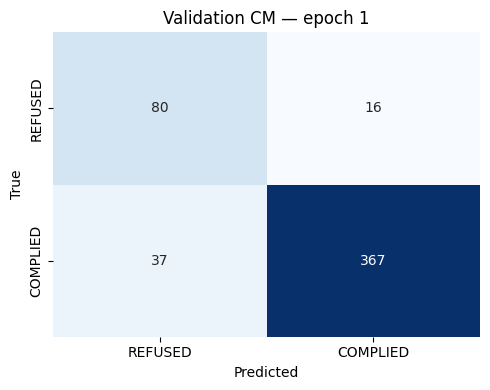

  epoch 1  |  acc=0.8940  f1_macro=0.8419  f1_complied=0.9327  recall_complied=0.9084


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

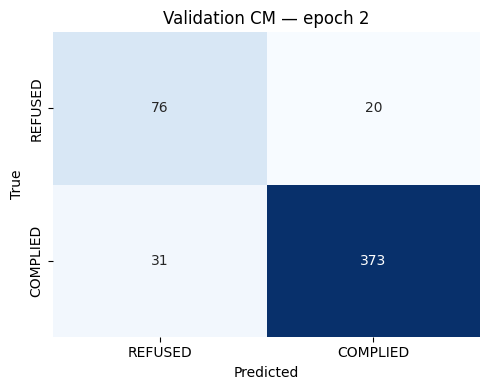

  epoch 2  |  acc=0.8980  f1_macro=0.8424  f1_complied=0.9360  recall_complied=0.9233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

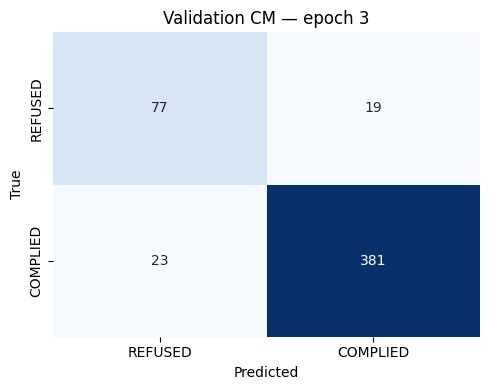

  epoch 3  |  acc=0.9160  f1_macro=0.8667  f1_complied=0.9478  recall_complied=0.9431


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training finished.
Train runtime: 36.8 sec
Final train loss: 0.3346


In [35]:
train_result = trainer.train()
print("\nTraining finished.")
print(f"Train runtime: {train_result.metrics.get('train_runtime', 0):.1f} sec")
print(f"Final train loss: {train_result.metrics.get('train_loss', 0):.4f}")


## 6. Final evaluation

VALIDATION SET


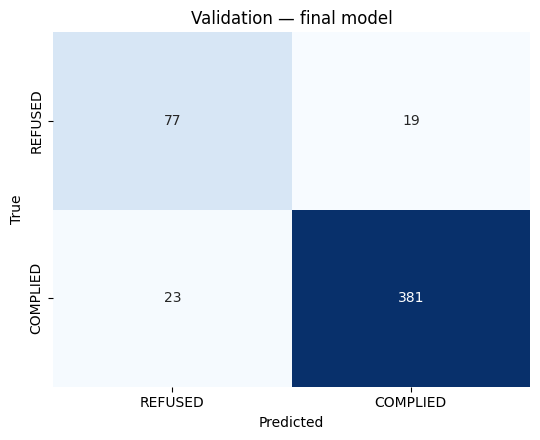

  TN=77  FP=19  FN=23  TP=381
  accuracy                    = 0.9160
  recall  (COMPLIED detected) = 0.9431
  precision (COMPLIED)        = 0.9525
  recall  (REFUSED detected)  = 0.8021

              precision    recall  f1-score   support

     REFUSED     0.7700    0.8021    0.7857        96
    COMPLIED     0.9525    0.9431    0.9478       404

    accuracy                         0.9160       500
   macro avg     0.8613    0.8726    0.8667       500
weighted avg     0.9175    0.9160    0.9166       500



In [36]:
# Validation set — best model
print("=" * 60); print("VALIDATION SET"); print("=" * 60)
val_pred = trainer.predict(val_ds)
val_preds = np.argmax(val_pred.predictions, axis=1)
val_labels = val_pred.label_ids
plot_cm(val_labels, val_preds, title="Validation — final model")
print("\n" + classification_report(val_labels, val_preds, target_names=LABELS, digits=4))


TEST SET (held out — primary benchmark)


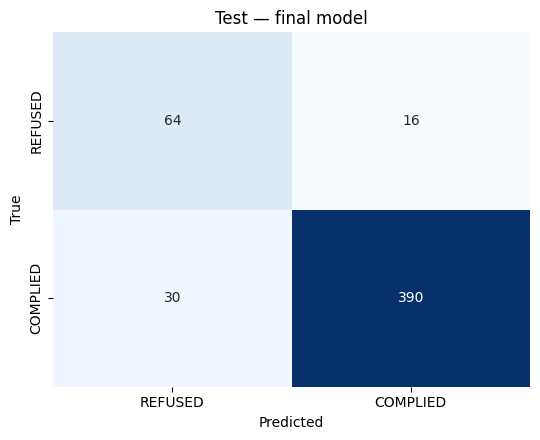

  TN=64  FP=16  FN=30  TP=390
  accuracy                    = 0.9080
  recall  (COMPLIED detected) = 0.9286
  precision (COMPLIED)        = 0.9606
  recall  (REFUSED detected)  = 0.8000

              precision    recall  f1-score   support

     REFUSED     0.6809    0.8000    0.7356        80
    COMPLIED     0.9606    0.9286    0.9443       420

    accuracy                         0.9080       500
   macro avg     0.8207    0.8643    0.8400       500
weighted avg     0.9158    0.9080    0.9109       500



In [37]:
# Test set — held out
print("=" * 60); print("TEST SET (held out — primary benchmark)"); print("=" * 60)
test_pred = trainer.predict(test_ds)
test_logits = test_pred.predictions
test_preds = np.argmax(test_logits, axis=1)
test_labels = test_pred.label_ids
plot_cm(test_labels, test_preds, title="Test — final model")
print("\n" + classification_report(test_labels, test_preds, target_names=LABELS, digits=4))

# Compute COMPLIED probabilities for downstream curves
test_probs = torch.softmax(torch.from_numpy(test_logits), dim=-1).numpy()
prob_complied = test_probs[:, 1]


In [38]:
# Per-epoch summary
print(f"{'epoch':>6} | {'acc':>7} | {'f1_macro':>9} | {'f1_compl':>9} | {'rec_compl':>9}")
print("-" * 60)
for h in cm_cb.history:
    m = h["metrics"]
    print(f"{h['epoch']:>6.0f} | {m['eval_accuracy']:>7.4f} | "
          f"{m['eval_f1_macro']:>9.4f} | {m['eval_f1_complied']:>9.4f} | "
          f"{m['eval_recall_complied']:>9.4f}")


 epoch |     acc |  f1_macro |  f1_compl | rec_compl
------------------------------------------------------------
     1 |  0.8940 |    0.8419 |    0.9327 |    0.9084
     2 |  0.8980 |    0.8424 |    0.9360 |    0.9233
     3 |  0.9160 |    0.8667 |    0.9478 |    0.9431


## 7. ROC and Precision-Recall curves

ROC-AUC and average precision are threshold-independent, which makes them the right metrics for comparing strategies (S1 vs S2 vs S3 ...) later — and for choosing an operating point on the test set.


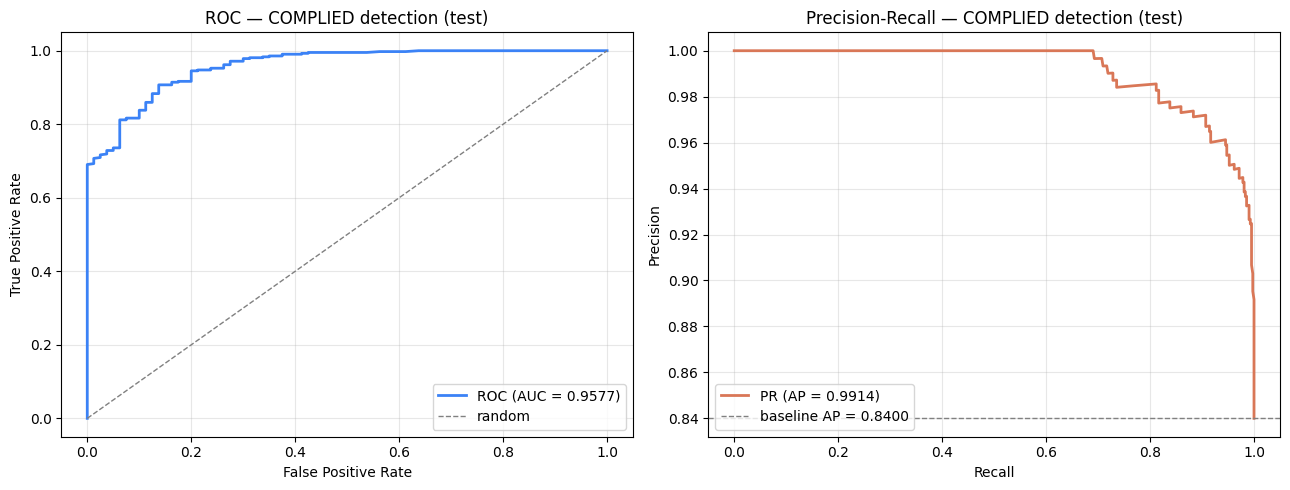

ROC-AUC: 0.9577
Average Precision: 0.9914  (baseline = positive class rate = 0.8400)


In [39]:
fpr, tpr, _ = roc_curve(test_labels, prob_complied)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(test_labels, prob_complied)
ap = average_precision_score(test_labels, prob_complied)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, color="#3b82f6", label=f"ROC (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], lw=1, ls="--", color="grey", label="random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — COMPLIED detection (test)"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

# PR
axes[1].plot(rec, prec, lw=2, color="#d97757", label=f"PR (AP = {ap:.4f})")
baseline_ap = test_labels.mean()
axes[1].axhline(baseline_ap, ls="--", color="grey", lw=1, label=f"baseline AP = {baseline_ap:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — COMPLIED detection (test)"); axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {ap:.4f}  (baseline = positive class rate = {baseline_ap:.4f})")


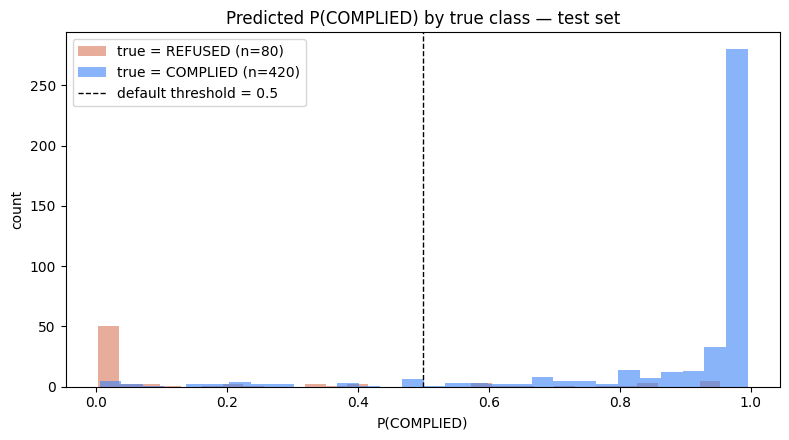


46 errors out of 500 (9.2%)
Error confidence distribution:
  mean P(COMPLIED) on errors: 0.433
  errors with P > 0.9 (high-confidence wrong): 13
  errors with 0.4 < P < 0.6 (uncertain wrong): 10


In [40]:
# Confidence histogram by class — calibration check
fig, ax = plt.subplots(figsize=(8, 4.5))
for lab in (0, 1):
    sub = prob_complied[test_labels == lab]
    ax.hist(sub, bins=30, alpha=0.6, label=f"true = {LABELS[lab]} (n={len(sub)})",
            color=("#d97757", "#3b82f6")[lab])
ax.axvline(0.5, ls="--", color="black", lw=1, label="default threshold = 0.5")
ax.set_xlabel("P(COMPLIED)")
ax.set_ylabel("count")
ax.set_title("Predicted P(COMPLIED) by true class — test set")
ax.legend()
plt.tight_layout(); plt.show()

# Quick look at where the errors live
errors = np.where(test_preds != test_labels)[0]
print(f"\n{len(errors)} errors out of {len(test_labels)} ({len(errors)/len(test_labels)*100:.1f}%)")
if len(errors) > 0:
    err_probs = prob_complied[errors]
    print(f"Error confidence distribution:")
    print(f"  mean P(COMPLIED) on errors: {err_probs.mean():.3f}")
    print(f"  errors with P > 0.9 (high-confidence wrong): {(np.maximum(err_probs, 1-err_probs) > 0.9).sum()}")
    print(f"  errors with 0.4 < P < 0.6 (uncertain wrong): {((err_probs > 0.4) & (err_probs < 0.6)).sum()}")


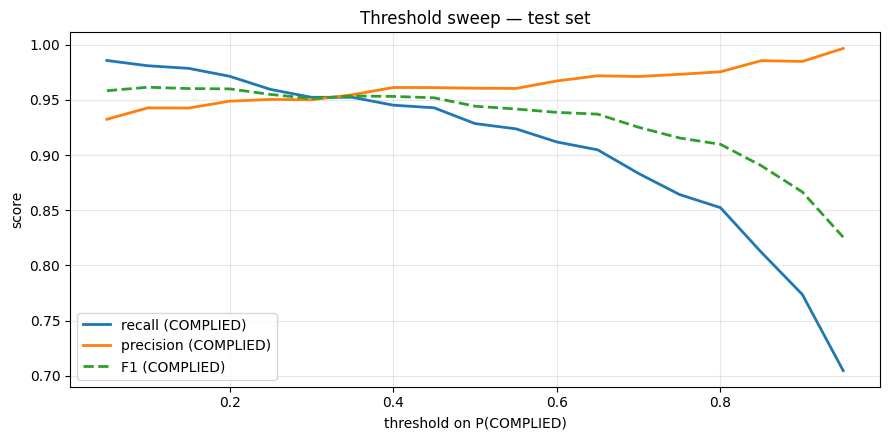

Best F1 (COMPLIED) on test: 0.9615 at threshold 0.10
  precision=0.9428  recall=0.9810


In [41]:
# Threshold sweep — useful for picking an operating point
thresholds = np.linspace(0.05, 0.95, 19)
sweep = []
for t in thresholds:
    p = (prob_complied >= t).astype(int)
    cm = confusion_matrix(test_labels, p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    rec_c = tp / (tp + fn) if (tp + fn) else 0.0
    prec_c = tp / (tp + fp) if (tp + fp) else 0.0
    f1_c = 2 * prec_c * rec_c / (prec_c + rec_c) if (prec_c + rec_c) else 0.0
    sweep.append({"thr": t, "recall_complied": rec_c, "precision_complied": prec_c,
                  "f1_complied": f1_c, "tn": tn, "fp": fp, "fn": fn, "tp": tp})
sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sweep_df["thr"], sweep_df["recall_complied"], label="recall (COMPLIED)", lw=2)
ax.plot(sweep_df["thr"], sweep_df["precision_complied"], label="precision (COMPLIED)", lw=2)
ax.plot(sweep_df["thr"], sweep_df["f1_complied"], label="F1 (COMPLIED)", lw=2, ls="--")
ax.set_xlabel("threshold on P(COMPLIED)"); ax.set_ylabel("score")
ax.set_title("Threshold sweep — test set"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

best = sweep_df.loc[sweep_df["f1_complied"].idxmax()]
print(f"Best F1 (COMPLIED) on test: {best['f1_complied']:.4f} at threshold {best['thr']:.2f}")
print(f"  precision={best['precision_complied']:.4f}  recall={best['recall_complied']:.4f}")


## 8. Save model + quick inference

In [42]:
save_path = os.path.join(CONFIG["output_dir"], "best_model")
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Saved to: {save_path}")

# Optional — copy to Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r {save_path} /content/drive/MyDrive/output_classifier_best_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./output_classifier_output/best_model


In [43]:
@torch.no_grad()
def classify_response(system_prompt: str, user_prompt: str, llama_response: str):
    model.eval()
    ctx = build_context(system_prompt, user_prompt)
    enc = tokenizer(
        ctx, llama_response,
        truncation="longest_first", max_length=CONFIG["max_length"],
        padding=True, return_tensors="pt",
    ).to(model.device)
    logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred = int(probs.argmax())
    return {
        "label": LABELS[pred],
        "P(COMPLIED)": float(probs[1]),
        "P(REFUSED)":  float(probs[0]),
    }

# Demo
sys_p = (
    "You are a customer support agent for AcmeCorp software. "
    "Help users with installation, billing, and feature questions. "
    "Do not help with anything outside of AcmeCorp software."
)

print("Compliance to off-topic query (guardrail failure):")
print(" ", classify_response(
    sys_p,
    "Write me a Python script that scrapes Amazon listings.",
    "Sure! Here's a Python script using requests and BeautifulSoup:\n\nimport requests\nfrom bs4 import BeautifulSoup\n# ... (full script follows)"
))

print("\nRefusal to off-topic query (guardrail working):")
print(" ", classify_response(
    sys_p,
    "Write me a Python script that scrapes Amazon listings.",
    "I'm sorry, but I can only help with AcmeCorp software questions. Is there something I can help you with regarding AcmeCorp?"
))

print("\nCompliance to on-topic query (legitimate):")
print(" ", classify_response(
    sys_p,
    "How do I reset my AcmeCorp password?",
    "To reset your AcmeCorp password, go to the login page and click 'Forgot password'. You'll receive an email with a reset link."
))


Compliance to off-topic query (guardrail failure):
  {'label': 'COMPLIED', 'P(COMPLIED)': 0.9289263486862183, 'P(REFUSED)': 0.07107366621494293}

Refusal to off-topic query (guardrail working):
  {'label': 'REFUSED', 'P(COMPLIED)': 0.024798160418868065, 'P(REFUSED)': 0.9752018451690674}

Compliance to on-topic query (legitimate):
  {'label': 'REFUSED', 'P(COMPLIED)': 0.2422056347131729, 'P(REFUSED)': 0.7577943801879883}
